# One-cell prototype: physics-informed photonic bit/qubit hybrid receiver

This notebook cell demonstrates an intensity-only phase-recovery prototype with a physics-informed PyTorch loss. It is designed for optical sensing/communications and educational modeling.


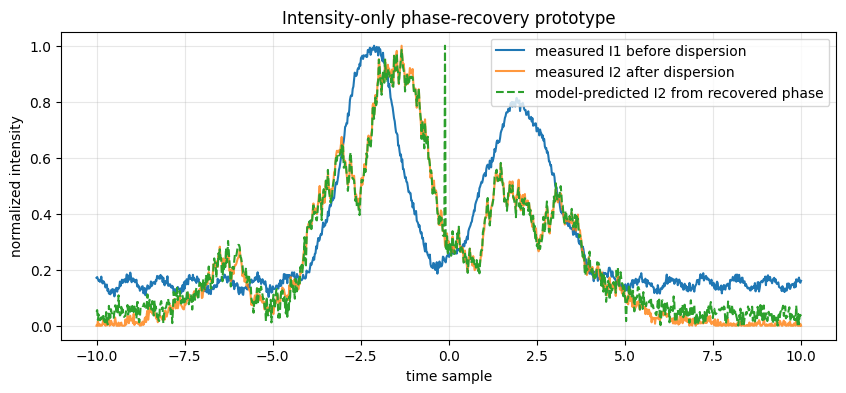

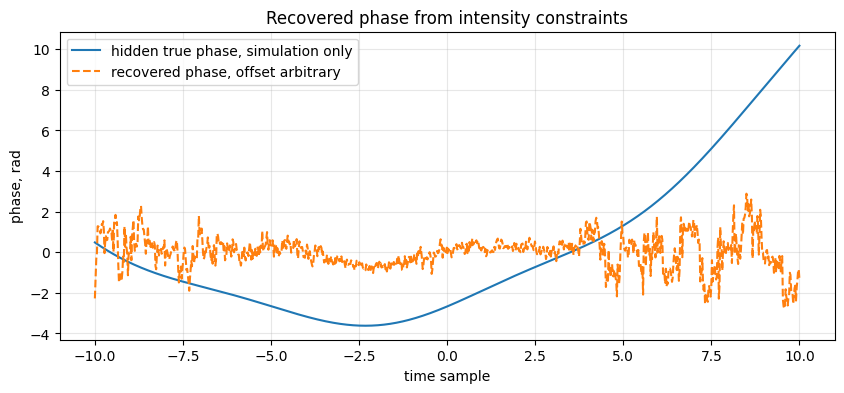

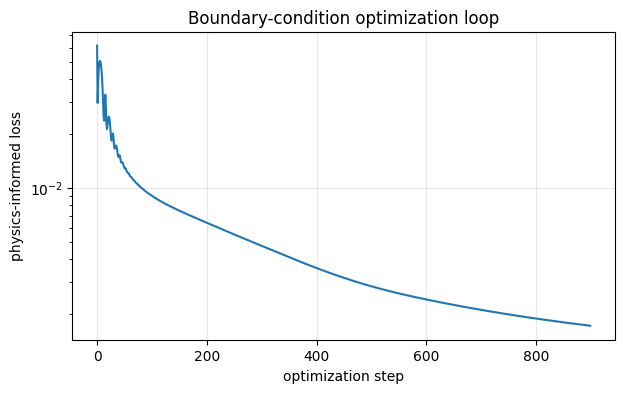

Device: cpu
Final loss: 0.0017159904616831237

How to replace simulation with real measurements:
1. Split the optical pulse into two paths or measure two planes/times.
2. Record I1(t) before dispersion: photodiode + oscilloscope/ADC.
3. Record I2(t) after known dispersion: fiber, chirped Bragg grating, or dispersive photonic chip.
4. Normalize both traces, align them in time, resample to the same N, and replace I1_meas_np and I2_meas_np.
5. Set beta2_L from the actual group-delay dispersion of the dispersive element.
6. Run the optimization. The learned phase is relative; absolute phase offset is not observable from intensity alone.


In [1]:
# Project 4 prototype: physics-informed photonic bit/qubit hybrid receiver
# One-cell notebook prototype for intensity-only phase recovery + ML refinement.
# Safe research use: optics, sensing, communications, education.

import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
except Exception as e:
    raise ImportError('Install PyTorch first: pip install torch') from e

# -----------------------------
# 1) Synthetic measurement setup
# -----------------------------
# E(t) = sqrt(I1) * exp(i phase). We pretend phase is hidden and only measure I1 and I2.
# I1: intensity before dispersion
# I2: intensity after known dispersive propagation

seed = 7
rng = np.random.default_rng(seed)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

N = 1024
T = 20.0
t = np.linspace(-T/2, T/2, N)
dt = t[1] - t[0]
freq = np.fft.fftfreq(N, d=dt)
omega = 2*np.pi*freq

# Photonic-bit-like pulse train: two Gaussian pulses with a weak modulation.
I1_np = (
    0.15
    + 1.0*np.exp(-(t+2.2)**2/1.2)
    + 0.75*np.exp(-(t-2.0)**2/1.8)
    + 0.05*np.cos(2*np.pi*0.55*t)**2
)
I1_np = I1_np / I1_np.max()

# Hidden true phase: chirp + smooth ripple. In a real experiment this is unknown.
phi_true_np = 0.45*t + 0.08*t**2 + 0.35*np.sin(0.8*t)
E1_true_np = np.sqrt(I1_np) * np.exp(1j*phi_true_np)

# Known dispersion transfer function. This is the physics model.
beta2_L = -1.8
H_np = np.exp(-0.5j * beta2_L * omega**2)
E2_true_np = np.fft.ifft(np.fft.fft(E1_true_np) * H_np)
I2_np = np.abs(E2_true_np)**2
I2_np = I2_np / I2_np.max()

# Add detector noise to simulate measurement.
noise = 0.01
I1_meas_np = np.clip(I1_np + noise*rng.standard_normal(N), 0, None)
I2_meas_np = np.clip(I2_np + noise*rng.standard_normal(N), 0, None)
I1_meas_np /= I1_meas_np.max()
I2_meas_np /= I2_meas_np.max()

# Convert to Torch.
torch.set_default_dtype(torch.float32)
I1 = torch.tensor(I1_meas_np, device=device)
I2 = torch.tensor(I2_meas_np, device=device)
omega_t = torch.tensor(omega, device=device)
H = torch.exp(-0.5j * beta2_L * omega_t**2)

# -----------------------------
# 2) Physics-informed trainable phase model
# -----------------------------
# This learns a phase phi(t) that makes propagated |E2|^2 match measured I2.
# Loss = intensity boundary loss + phase smoothness + optional bit/qubit regularizer.

phase = nn.Parameter(0.02*torch.randn(N, device=device))
optimizer = torch.optim.Adam([phase], lr=0.03)

loss_history = []
for step in range(900):
    E1 = torch.sqrt(I1 + 1e-9) * torch.exp(1j*phase)
    E2 = torch.fft.ifft(torch.fft.fft(E1) * H)
    I2_pred = torch.abs(E2)**2
    I2_pred = I2_pred / (I2_pred.max() + 1e-9)

    # Boundary condition: output intensity should match measured output intensity.
    boundary_loss = torch.mean((I2_pred - I2)**2)

    # Smoothness: physical phase usually does not jump violently sample-to-sample.
    dphi = phase[1:] - phase[:-1]
    smooth_loss = torch.mean(dphi**2)

    # Hybrid photonic-bit/qubit-inspired term:
    # keep normalized complex field energy close to 1, like a stable state vector.
    norm_loss = (torch.mean(torch.abs(E1)**2) - torch.mean(I1))**2

    loss = boundary_loss + 2e-3*smooth_loss + 1e-3*norm_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(float(loss.detach().cpu()))

# Results.
with torch.no_grad():
    E1_rec = torch.sqrt(I1 + 1e-9) * torch.exp(1j*phase)
    E2_rec = torch.fft.ifft(torch.fft.fft(E1_rec) * H)
    I2_rec = torch.abs(E2_rec)**2
    I2_rec = I2_rec / I2_rec.max()
    phi_rec_np = phase.detach().cpu().numpy()
    I2_rec_np = I2_rec.detach().cpu().numpy()

# Phase is only meaningful up to offset/wrapping; unwrap for display.
phi_rec_unwrapped = np.unwrap(phi_rec_np)
phi_true_unwrapped = np.unwrap(phi_true_np)
phi_rec_centered = phi_rec_unwrapped - np.mean(phi_rec_unwrapped)
phi_true_centered = phi_true_unwrapped - np.mean(phi_true_unwrapped)

# -----------------------------
# 3) Plots
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(t, I1_meas_np, label='measured I1 before dispersion')
plt.plot(t, I2_meas_np, label='measured I2 after dispersion', alpha=0.8)
plt.plot(t, I2_rec_np, '--', label='model-predicted I2 from recovered phase')
plt.xlabel('time sample')
plt.ylabel('normalized intensity')
plt.title('Intensity-only phase-recovery prototype')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(t, phi_true_centered, label='hidden true phase, simulation only')
plt.plot(t, phi_rec_centered, '--', label='recovered phase, offset arbitrary')
plt.xlabel('time sample')
plt.ylabel('phase, rad')
plt.title('Recovered phase from intensity constraints')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,4))
plt.semilogy(loss_history)
plt.xlabel('optimization step')
plt.ylabel('physics-informed loss')
plt.title('Boundary-condition optimization loop')
plt.grid(True, alpha=0.3)
plt.show()

print('Device:', device)
print('Final loss:', loss_history[-1])
print('\nHow to replace simulation with real measurements:')
print('1. Split the optical pulse into two paths or measure two planes/times.')
print('2. Record I1(t) before dispersion: photodiode + oscilloscope/ADC.')
print('3. Record I2(t) after known dispersion: fiber, chirped Bragg grating, or dispersive photonic chip.')
print('4. Normalize both traces, align them in time, resample to the same N, and replace I1_meas_np and I2_meas_np.')
print('5. Set beta2_L from the actual group-delay dispersion of the dispersive element.')
print('6. Run the optimization. The learned phase is relative; absolute phase offset is not observable from intensity alone.')
